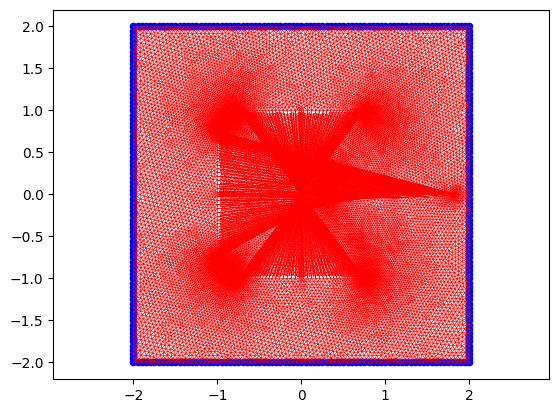

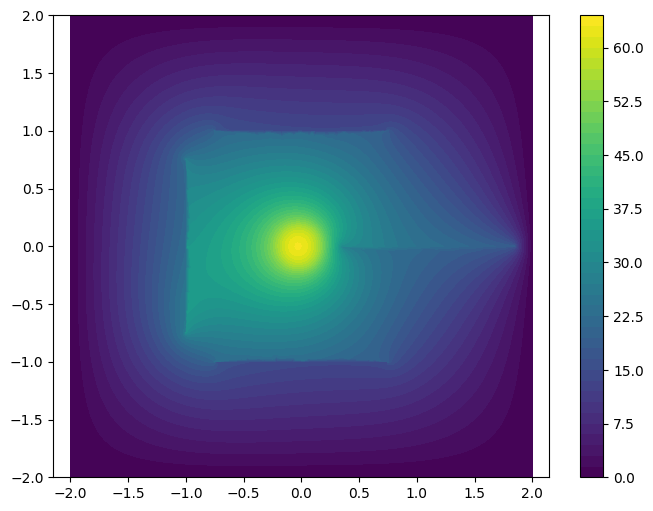

In [1]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

D = 2
MS_REGULAR = 0.05
MS_MIN = 0.005

def distribution_func(size_min, size_max, portal):
    line1, line2 = portal
    xm1, ym1, l1, theta1 = line1
    xm2, ym2, l2, theta2 = line2
    alpha1 = theta1 + np.pi / 2
    alpha2 = theta2 + np.pi / 2
    x11, y11, x12, y12 = (
        xm1 - l1 / 2 * np.cos(alpha1),
        ym1 - l1 / 2 * np.sin(alpha1),
        xm1 + l1 / 2 * np.cos(alpha1),
        ym1 + l1 / 2 * np.sin(alpha1),
    )
    x21, y21, x22, y22 = (
        xm2 - l2 / 2 * np.cos(alpha2),
        ym2 - l2 / 2 * np.sin(alpha2),
        xm2 + l2 / 2 * np.cos(alpha2),
        ym2 + l2 / 2 * np.sin(alpha2),
    )
    dx1, dy1 = [(x12 - x11) / l1, (y12 - y11) / l1]
    dx2, dy2 = [(x22 - x21) / l2, (y22 - y21) / l2]

    half_distance = (l1 + l2) / 4

    def _base_distribution_func(x):
        # return (np.exp(x) - 1) / (np.exp(1) - 1)
        # return x
        return np.sin(np.pi / 2 * x) ** 2

    def _total_segment_length(size_min, size_max, num_segs):
        d = 0
        for i in range(num_segs):
            d += (
                _base_distribution_func(i / num_segs) * (size_max - size_min) + size_min
            )
        return d

    num_segs_min = int(half_distance / size_max) - 1
    num_segs_max = int(half_distance / size_min) + 1
    while True:
        num_segs = (num_segs_min + num_segs_max) // 2
        d = _total_segment_length(size_min, size_max, num_segs)
        if (
            _total_segment_length(size_min, size_max, num_segs - 1)
            <= half_distance
            <= d
        ):
            break
        elif (
            _total_segment_length(size_min, size_max, num_segs + 1)
            >= half_distance
            >= d
        ):
            num_segs += 1
            break
        elif d > half_distance:
            num_segs_max = num_segs
        else:
            num_segs_min = num_segs
    interp_nodes = [0.0] * (2 * num_segs + 1)
    for i in range(num_segs - 1):
        interp_nodes[i + 1] = (
            interp_nodes[i]
            + _base_distribution_func(i / num_segs) * (size_max - size_min)
            + size_min
        )
    interp_nodes[num_segs] = half_distance
    for i in range(num_segs + 1, 2 * num_segs + 1):
        interp_nodes[i] = 2 * half_distance - interp_nodes[2 * num_segs - i]

    p1 = [(0, 0)] * len(interp_nodes)
    p2 = [(0, 0)] * len(interp_nodes)
    for i, d in enumerate(interp_nodes):
        d /= half_distance * 2
        d1 = d * l1
        d2 = d * l2
        p1[i] = (x11 + dx1 * d1, y11 + dy1 * d1)
        p2[i] = (x21 + dx2 * d2, y21 + dy2 * d2)

    return p1, p2


def generate_domain_mesh(
    portals,
    domain_side_length=10.0,
    mesh_size_regular=0.1,
    mesh_size_min=0.01,
    switch_portal=True,
    plot_portal_points=False,
):

    if mesh_size_regular < mesh_size_min:
        raise ValueError("网格尺寸不合理")

    def add_points_to_mesh(points):
        n = len(points)
        point_tags = [0] * n
        line_tags = [0] * (n - 1)
        for i, (x, y) in enumerate(points):
            point_tags[i] = gmsh.model.occ.addPoint(x, y, 0, mesh_size_regular)
        for i in range(n - 1):
            line_tags[i] = gmsh.model.occ.addLine(point_tags[i], point_tags[i + 1])
        return point_tags, line_tags

    def add_portal_to_mesh(portal):
        p1, p2 = distribution_func(mesh_size_min, mesh_size_regular, portal)
        p1_tags, l1_tags = add_points_to_mesh(p1)
        p2_tags, l2_tags = add_points_to_mesh(p2)
        return p1_tags, p2_tags, l1_tags + l2_tags

    gmsh.initialize()
    gmsh.model.add("domain_mesh")
    D = domain_side_length

    domain = gmsh.model.occ.addRectangle(-D, -D, 0, 2 * D, 2 * D)

    portal_points_tags = []
    line_tags = []
    for portal in portals:
        p1_tags, p2_tags, l_tags = add_portal_to_mesh(portal)
        portal_points_tags.append((p1_tags, p2_tags))
        line_tags.extend((1, lt) for lt in l_tags)

    if line_tags:
        gmsh.model.occ.fragment([(2, domain)], line_tags)

    gmsh.model.occ.synchronize()

    if line_tags:
        for lt in line_tags:
            gmsh.model.mesh.setTransfiniteCurve(lt[1], 1)

    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size_regular)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size_min)
    gmsh.model.mesh.generate(2)

    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    Nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

    _, _, node_tags = gmsh.model.mesh.getElements(2, domain)
    Elements = np.array(node_tags[0], dtype=int).reshape(-1, 3) - 1
    
    Elements_geom = Elements.copy()


    if switch_portal == True:
        def _tri_centroid_xy(a, b, c):
            x1, y1 = Nodes[a]
            x2, y2 = Nodes[b]
            x3, y3 = Nodes[c]
            return (x1 + x2 + x3) / 3, (y1 + y2 + y3) / 3
        for i, portal in enumerate(portals):
            line1, line2 = portal
            x, y, _, theta = zip(line1, line2)
            p1, p2 = portal_points_tags[i]
            p1, p2 = p1[1:-1], p2[1:-1]
            for i in range(len(p1)):
                n1, _, _ = gmsh.model.mesh.getNodes(0, p1[i])
                p1[i] = n1[0] - 1
                n2, _, _ = gmsh.model.mesh.getNodes(0, p2[i])
                p2[i] = n2[0] - 1

            inner_nodes = {n: 0 for n in p1} | {n: 1 for n in p2}
            inner_nodes_map = {a: b for a, b in zip(p1, p2)} | {
                b: a for a, b in zip(p1, p2)
            }
            swap_nodes = set()
            for j, Ele in enumerate(Elements):
                for k, node_tag in enumerate(Ele):
                    if node_tag in inner_nodes:
                        p_id = inner_nodes[node_tag]
                        a, b, c = Ele

                        tri_x, tri_y = _tri_centroid_xy(a, b, c)

                        co, si = np.cos(theta[p_id]), np.sin(theta[p_id])
                        dx, dy = tri_x - x[p_id], tri_y - y[p_id]
                        if co * dx + si * dy < 0:
                            swap_nodes.add((j, k, inner_nodes_map[node_tag]))
            for j, k, new_node in swap_nodes:
                Elements[j][k] = new_node
        

    tol = mesh_size_min * 0.1
    boundary_nodes = np.where(
        (np.abs(Nodes[:, 0] - D) < tol)
        | (np.abs(Nodes[:, 0] + D) < tol)
        | (np.abs(Nodes[:, 1] - D) < tol)
        | (np.abs(Nodes[:, 1] + D) < tol)
    )[0]

    def _plot_portal_points(portal_points_tags):
        xs, ys = [], []
        for p1s, p2s in portal_points_tags:
            lp = 0
            for t1, t2 in zip(p1s, p2s):
                lp += 1
                for t in (t1, t2):
                    nt, _, _ = gmsh.model.mesh.getNodes(0, t)
                    xs.append(Nodes[nt[0] - 1][0])
                    ys.append(Nodes[nt[0] - 1][1])

        plt.plot(xs, ys, "ko", markersize=0.1)
    if plot_portal_points:
        _plot_portal_points(portal_points_tags)

    gmsh.finalize()

    return Nodes, boundary_nodes, Elements, Elements_geom


def plot_mesh(Nodes, Elements, show_ele_tags=False, boundary_nodes=None, fig_name="meshfig.svg"):
    for i, (a, b, c) in enumerate(Elements):
        x1, y1 = Nodes[a]
        x2, y2 = Nodes[b]
        x3, y3 = Nodes[c]
        x = (x1 + x2 + x3) / 3
        y = (y1 + y2 + y3) / 3
        plt.plot([x1, x2, x3, x1], [y1, y2, y3, y1], color="r", linewidth=0.3)

        area = 0.5 * abs((x2 - x1) * (y3 - y1) - (y2 - y1) * (x3 - x1))
        font = np.sqrt(area) / D * 40
        if show_ele_tags:
            plt.text(x, y, f"{i}", fontsize=font, ha="center", va="center")

    if boundary_nodes is not None:
        plt.scatter(Nodes[boundary_nodes, 0], Nodes[boundary_nodes, 1], color="b", s=20)

    plt.axis("equal")
    plt.savefig(fig_name)
    plt.plot()
    
    
def solve_poisson(Nodes, Elements, boundary_nodes, func_domain, func_boundary):
    num_N = len(Nodes)
    K = np.zeros((num_N, num_N))
    F = np.zeros(num_N)

    for id1, id2, id3 in Elements:
        x1, y1 = Nodes[id1]
        x2, y2 = Nodes[id2]
        x3, y3 = Nodes[id3]
        xc = (x1 + x2 + x3) / 3
        yc = (y1 + y2 + y3) / 3
        b = np.array([y2 - y3, y3 - y1, y1 - y2])
        c = np.array([x3 - x2, x1 - x3, x2 - x1])
        area = 0.5 * abs((x2 - x1) * (y3 - y1) - (y2 - y1) * (x3 - x1))

        A_loc = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                A_loc[i, j] = (b[i] * b[j] + c[i] * c[j]) / (4 * area)

        f_val = func_domain(xc, yc)
        B_loc = area * f_val / 3 * np.ones(3)
        ids = [id1, id2, id3]

        for i in range(3):
            F[ids[i]] += B_loc[i]
            for j in range(3):
                K[ids[i], ids[j]] += A_loc[i, j]

    for n in boundary_nodes:
        K[n, :] = 0
        K[:, n] = 0
        K[n, n] = 1
        F[n] = func_boundary(Nodes[n, 0], Nodes[n, 1])
    
    U = np.linalg.solve(K, F)

    return U


def plot_solution(Nodes, Elements_geom, U):
    triang = mtri.Triangulation(Nodes[:, 0], Nodes[:, 1], Elements_geom)
    plt.figure(figsize=(8, 6))
    plt.tricontourf(triang, U, levels=50)
    plt.colorbar()

    plt.axis("equal")
    plt.savefig("solutionfig.svg")
    plt.show()
    

portals = [
    [(1.1, 0, 1.5, np.pi / 2), (-1, 0, 1.5, np.pi)],
    [(0, 1.001, 1.5, np.pi / 2), (0, -1.001, 1.5, -np.pi / 2)],
]

Nodes, boundary_nodes, Elements, Elements_geom = generate_domain_mesh(
    portals,
    domain_side_length=D,
    mesh_size_regular=MS_REGULAR,
    mesh_size_min=MS_MIN,
    switch_portal=True,
    plot_portal_points=True,
)

plot_mesh(
    Nodes,
    Elements,
    show_ele_tags=False,
    boundary_nodes=boundary_nodes,
)


def func_domain_source(x, y):
    xc, yc = 0, 0
    r = np.sqrt((x - xc) ** 2 + (y - yc) ** 2)
    if r < 0.2:
        return 1000
    else:
        return 0

func_boundary = lambda x, y: 0

U = solve_poisson(Nodes, Elements, boundary_nodes, func_domain_source, func_boundary)
plot_solution(Nodes, Elements_geom, U)